# ESCUELA DE CIENCIA DE LA COMPUTACIÓN
---


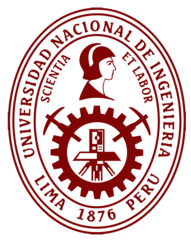

---
### Curso: Computación Gráfica (CC431A)
### Profesor: Mg. Peter Jonathan Montalvo Garcia
---
---
# TEMA: MENEJO DE CAMARAS
---
---

# Manejo de Camara [1]
Detecta las camaras que estan habilitadas en la computadora (la informacion lo imprime en terminal) y solo abre la camara por defecto que esta en la computadora (esta con el indice 0),
o si queremos usar otra camara se cambia el indice de la camara que se requiera. Solo toma una frame de la camara seleccionada.

In [1]:
import cv2

# vemos que camaras estan habilitadas en el computador
for i in range(5):  # intenta con los primeros 5 dispositivos
    cap = cv2.VideoCapture(i)
    if cap.isOpened():
        print(f"[INFO] Camara encontrada en el índice {i}")
        cap.release()
        
# Abrir la cámara (0 para la cámara predeterminada)
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("[INFO] No se pudo abrir la cámara")
else:
    ret, frame = cap.read()
    if ret:
        # mostrar el "TEXTO" , "IMAGEN(frame)" en una ventana
        cv2.imshow("Toma de una imagen con la camara de la computadora", frame)
        # Espera indefinida hasta que se presione una tecla
        cv2.waitKey(0)
        
# liberar la cámara y cerrar ventanas
cap.release()
# cierra todas las ventanas
cv2.destroyAllWindows()
print("[INFO] FIN DEL PROGRAMA ..........")

[INFO] Camara encontrada en el índice 0
[INFO] FIN DEL PROGRAMA ..........


# Manejo de Camara [2]
Detecta la camara por defecto que esta en la computadora (de indice 0), enciende la camara en tiempo real hasta que el usuario lo cierre.

In [4]:
import cv2
# Abrir la cámara (0 para la cámara predeterminada)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("[INFO] No se pudo abrir la camara")
    exit()

while True:
    ret, frame = cap.read()
    if not ret:
        print("[INFO] No se pudo leer el frame")
        break

    # mostrar el texto y frame en una ventana
    cv2.imshow("Camara Computadora - Presiona 'q' para SALIR", frame)

    # Salir si el usuario presiona la tecla 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# liberar la cámara y cerrar ventanas
cap.release()
cv2.destroyAllWindows()
print("[INFO] FIN DEL PROGRAMA ..........")

[INFO] FIN DEL PROGRAMA ..........


# Manejo de Camara [3]
Abre dos camaras simultaneamente (de indice 0 y 1) en forma explicita. Si una camara no esta, no despliega el programa.

In [5]:
import cv2
# Abrir las dos cámaras (0 y 1)
cam0 = cv2.VideoCapture(0)
cam1 = cv2.VideoCapture(1)

# Verificar si ambas cámaras se abrieron correctamente
if not cam0.isOpened():
    print("[INFO] No se pudo abrir la camara 0")
if not cam1.isOpened():
    print("[INFO] No se pudo abrir la camara 1")

if cam0.isOpened() and cam1.isOpened():
    while True:
        ret0, frame0 = cam0.read()
        ret1, frame1 = cam1.read()

        if ret0:
            cv2.imshow("Camara 0 - Presione 'q' para SALIR", frame0)
        if ret1:
            cv2.imshow("Camara 1 - Presione 'q' para SALIR", frame1)

        # Salir con la tecla 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Liberar recursos
    cam0.release()
    cam1.release()
    cv2.destroyAllWindows()
else:
    print("[INFO]  Una o ambas cámaras no se pudieron abrir correctamente")

print("[INFO] FIN DEL PROGRAMA ..........")

[INFO] No se pudo abrir la camara 1
[INFO]  Una o ambas cámaras no se pudieron abrir correctamente
[INFO] FIN DEL PROGRAMA ..........


# Manejo de Camara [4]
Abre multiples camaras simultaneamente en forma explicita. Despliega las camaras que estuvieran conectadas

In [6]:
import cv2
# detecta las camaaras conectadas
def detectar_camaras_disponibles(max_dispositivos=10):
    camaras = []
    for i in range(max_dispositivos):
        cam = cv2.VideoCapture(i)
        if cam.isOpened():
            print(f"[INFO] Camara detectada en el indice {i}")
            camaras.append((i, cam))
        else:
            cam.release()
    return camaras

# detectar y abrir todas las cámaras
camaras_abiertas = detectar_camaras_disponibles()

if not camaras_abiertas:
    print("[INFO] No se encontraron camaras disponibles.")
else:
    while True:
        for i, cam in camaras_abiertas:
            ret, frame = cam.read()
            if ret:
                cv2.imshow(f"Camara {i} - Presionar 'q' para SALIR", frame)
        
        # salir si se presiona 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Liberar todas las cámaras y cerrar ventanas
    for _, cam in camaras_abiertas:
        cam.release()
    cv2.destroyAllWindows()
    
    print("[INFO] FIN DEL PROGRAMA ..........")

[INFO] Camara detectada en el indice 0
[INFO] FIN DEL PROGRAMA ..........


# Manejo de Camara [5]
Abre multiples camaras simultaneamente en forma explicita. Despliega las camaras en forma de videos, si presiona 's' toma imagenes y se aprieta 'q' salen del programa.

In [8]:
import cv2
import os
from datetime import datetime

# detecta las camaras instaladas
def detectar_camaras_disponibles(max_dispositivos=10):
    camaras = []
    for i in range(max_dispositivos):
        cam = cv2.VideoCapture(i)
        if cam.isOpened():
            print(f"[INFO] Camara detectada en el indice {i}")
            camaras.append((i, cam))
        else:
            cam.release()
    return camaras

# Ruta absoluta donde está el script
# directorio_base = os.path.dirname(os.path.abspath(__file__))
directorio_base = os.getcwd()
ruta_salida = os.path.join(directorio_base, "Solo_Fotos-Camara_5")
os.makedirs(ruta_salida, exist_ok=True)

# Detectar y abrir todas las cámaras
camaras_abiertas = detectar_camaras_disponibles()

if not camaras_abiertas:
    print("[INFO] No se encontraron camaras disponibles.")
else:
    print("[INFO] Presiona 's' para capturar fotos, 'q' para SALIR")
    while True:
        frames_actuales = []
        for i, cam in camaras_abiertas:
            ret, frame = cam.read()
            if ret:
                cv2.imshow(f"Camara {i} - Presiona 's' para capturar fotos, 'q' para SALIR", frame)
                frames_actuales.append((i, frame))
        
        tecla = cv2.waitKey(1) & 0xFF

        if tecla == ord('s'):
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            for i, frame in frames_actuales:
                nombre_archivo = f"{ruta_salida}/camara_{i}_{timestamp}.png"
                cv2.imwrite(nombre_archivo, frame)
                print(f"[INFO] Imagen guardada: {nombre_archivo}")
        
        elif tecla == ord('q'):
            break

    # Liberar cámaras y cerrar ventanas
    for _, cam in camaras_abiertas:
        cam.release()
    cv2.destroyAllWindows()

print("[INFO] FIN DEL PROGRAMA ..........")

[INFO] Camara detectada en el indice 0
[INFO] Presiona 's' para capturar fotos, 'q' para SALIR
[INFO] Imagen guardada: d:\CICLO 2026-1 UNI\Project_Grafica\[2] CODIGO_YOLO\[2A] MANEJO CAMAR\Solo_Fotos-Camara_5/camara_0_20260526_230028.png
[INFO] FIN DEL PROGRAMA ..........


# Manejo de Camara [6]
Abre multiples camaras simultaneamente en forma explicita. Despliega las camaras en forma de videos, graba automaticamente video y toma fotos en un tiempo t=60*2=120 segundos, si se aprieta 'q' salen del programa. Si se aprieta 's' toma una foto de la camara.

In [10]:
import cv2
import os
import time
from datetime import datetime

# ======================= CONFIGURACION ========================
# Ruta absoluta donde esta el script
# directorio_base = os.path.dirname(os.path.abspath(__file__))
directorio_base = os.getcwd()
CARPETA_RAIZ = os.path.join(directorio_base, "Fotos_Videos-Camara_6")
os.makedirs(CARPETA_RAIZ, exist_ok=True)
#creacion de subcarpetas
CARPETA_CAPTURAS = os.path.join(CARPETA_RAIZ, "capturas")
CARPETA_VIDEOS = os.path.join(CARPETA_RAIZ, "videos")
# Crear carpetas si no existen
os.makedirs(CARPETA_CAPTURAS, exist_ok=True)
os.makedirs(CARPETA_VIDEOS, exist_ok=True)
# definicion de tiempos
TIEMPO_ENTRE_FOTOS = 5  # segundos entre capturas automaticas
DURACION_MAXIMA_SEGUNDOS = 60 * 2  # duracion maxima del programa (opcional)

# ============== FUNCION PARA DETECTAR CAMARAS ================
def detectar_camaras_disponibles(max_dispositivos=10):
    camaras = []
    for i in range(max_dispositivos):
        cam = cv2.VideoCapture(i)
        if cam.isOpened():
            print(f"[INFO] Cámara detectada en el índice {i}")
            cam.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
            cam.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
            camaras.append((i, cam))
        else:
            cam.release()
    return camaras

# ==================== INICIALIZACION =========================
camaras_abiertas = detectar_camaras_disponibles()
video_writers = {}
fps = 20  # fotogramas por segundo para los videos
cuatrocc = cv2.VideoWriter_fourcc(*'XVID')  # codec para el video
inicio_programa = time.time()
ultimo_guardado = time.time()

# Crear grabadores de video
for i, cam in camaras_abiertas:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    nombre_video = os.path.join(CARPETA_VIDEOS, f"camara_{i}_{timestamp}.avi")
    video_writers[i] = cv2.VideoWriter(nombre_video, cuatrocc, fps, (640, 480))
    print(f"[INFO] Grabando video: {nombre_video}")

if not camaras_abiertas:
    print("[ERROR] No se encontraron camaras disponibles.")
    exit()

print("[INFO] Grabacion iniciada. Presiona 'q' para salir.")

# ========== BUCLE PRINCIPAL TOMA DE FOTOS Y VIDEO ==========
while True:
    frames_actuales = []
    for i, cam in camaras_abiertas:
        ret, frame = cam.read()
        if ret:
            # mostrar en ventana
            cv2.imshow(f"Camara {i} - Presiona 'q' para salir", frame)
            frames_actuales.append((i, frame))
            # grabar en video
            video_writers[i].write(frame)

    tiempo_actual = time.time()

    # Guardar imagenes cada cierto tiempo
    if tiempo_actual - ultimo_guardado >= TIEMPO_ENTRE_FOTOS:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        for i, frame in frames_actuales:
            nombre_img = os.path.join(CARPETA_CAPTURAS, f"camara_{i}_{timestamp}.png")
            cv2.imwrite(nombre_img, frame)
            print(f"[✔] Imagen guardada: {nombre_img}")
        ultimo_guardado = tiempo_actual

    # Salir con 'q' o tiempo maximo alcanzado
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    if tiempo_actual - inicio_programa > DURACION_MAXIMA_SEGUNDOS:
        print("[INFO] Tiempo máximo alcanzado. Finalizando...")
        break

# =================== CIERRE CAMARAS =======================
for i, cam in camaras_abiertas:
    cam.release()
    video_writers[i].release()

cv2.destroyAllWindows()

print("[INFO] Cámaras cerradas. Archivos guardados correctamente.")
print("[INFO] Cámaras cerradas. Archivos guardados en la carpeta 'RESULTADOS'........")


[INFO] Cámara detectada en el índice 0
[INFO] Grabando video: d:\CICLO 2026-1 UNI\Project_Grafica\[2] CODIGO_YOLO\[2A] MANEJO CAMAR\Fotos_Videos-Camara_6\videos\camara_0_20260526_230257.avi
[INFO] Grabacion iniciada. Presiona 'q' para salir.
[✔] Imagen guardada: d:\CICLO 2026-1 UNI\Project_Grafica\[2] CODIGO_YOLO\[2A] MANEJO CAMAR\Fotos_Videos-Camara_6\capturas\camara_0_20260526_230302.png
[INFO] Cámaras cerradas. Archivos guardados correctamente.
[INFO] Cámaras cerradas. Archivos guardados en la carpeta 'RESULTADOS'........
